# Data Scientist Professional Practical Exam Submission
## Recipe Site Traffic (Tasty Bytes)

This report covers data validation, exploratory analysis, model development, model evaluation, a business metric, and a final summary with recommendations.

In [ ]:
# First import all needed packages for this project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics import precision_score, recall_score

## 1. Data Validation

Explore the raw dataset and call it `df_raw` to clearly distinguish it from the processed dataframe. Since the `recipe` column just includes indexing for the data (a unique identifier with no predictive value), I decided to drop it, since I prefer the natural Python indexing from 0.

In [11]:
df_raw = pd.read_csv("recipe_site_traffic_2212.csv")
print(df_raw.info())
df_raw = df_raw.drop("recipe", axis=1)
num_duplicates = df_raw.duplicated().sum()
print(f"Total duplicate rows: {num_duplicates}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB
None
Total duplicate rows: 23


Now it's time to clean the data ; check the different entries for the object columns, find na data, and clean up appropriately to the data type.

In [12]:
print(df_raw.columns)
for col in df_raw.select_dtypes("object").columns:
    print(f"column name: {col} \n{df_raw[col].value_counts()}\n")

for col in df_raw.columns:
    print(f"{col}: {df_raw[col].isna().sum()} na's")
# Though i suspect the duplicate columns come from the mostly nan rows, it's always good practice to drop them.
df = df_raw.drop_duplicates().copy()
# I suspect that al 52 na's in the 4 columns are from the same 52 rows, let's drop them and check if this cleans it.
df = df.dropna(subset=['calories'])

# The chicken breast category should be in chicken.
df["category"] = df["category"].str.replace("Chicken Breast", "Chicken").astype('category')

# Since the snack entries are just 3 samples its easier to just drop them.
df = df[~df["servings"].str.contains("snack", case=False, na=False)]
df["servings"] = df["servings"].str.extract(r'(\d+)').astype("int64")
df["high_traffic"] = df["high_traffic"].map({"High": True}).fillna(False)

print("Missing values per column:")
print(df.isna().any())
print("\nDataFrame Info:")
df.info()
print("\nCategory counts:")
print(df["category"].value_counts())

Index(['calories', 'carbohydrate', 'sugar', 'protein', 'category', 'servings',
       'high_traffic'],
      dtype='object')
column name: category 
category
Breakfast         106
Chicken Breast     98
Beverages          92
Lunch/Snacks       89
Potato             88
Pork               84
Vegetable          83
Dessert            83
Meat               79
Chicken            74
One Dish Meal      71
Name: count, dtype: int64

column name: servings 
servings
4               389
6               197
2               183
1               175
4 as a snack      2
6 as a snack      1
Name: count, dtype: int64

column name: high_traffic 
high_traffic
High    574
Name: count, dtype: int64

calories: 52 na's
carbohydrate: 52 na's
sugar: 52 na's
protein: 52 na's
category: 0 na's
servings: 0 na's
high_traffic: 373 na's
Missing values per column:
calories        False
carbohydrate    False
sugar           False
protein         False
category        False
servings        False
high_traffic    False
dtype:

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_13460\4192578448.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["high_traffic"] = df["high_traffic"].map({"High": True}).fillna(False)


Now that we've checked if the data is clean, let's see if the float and integer data makes sense.

In [13]:
# Now that we've checked if the data is clean, let's see if the float and integer data makes sense.
df.describe()

,calories,carbohydrate,sugar,protein,servings
count,892.000000,892.000000,892.000000,892.000000,892.000000
mean,433.484989,35.062971,9.043206,24.142018,3.454036
std,450.997596,44.005332,14.699529,36.429244,1.736618
min,0.140000,0.030000,0.010000,0.000000,1.000000
25%,110.145000,8.320000,1.687500,3.177500,2.000000
50%,287.010000,21.480000,4.545000,10.775000,4.000000
75%,595.930000,44.907500,9.800000,30.015000,4.000000
max,3633.160000,530.420000,148.750000,363.360000,6.000000


This all seems reasonable, since there are no weird outliers like 100k calories, the means also resemble normal values for recipes.

## 2. Exploratory Analysis

Now we describe the data, firstly with single variable plots.

### Single variable graphic 1: boxplots of the nutritional values

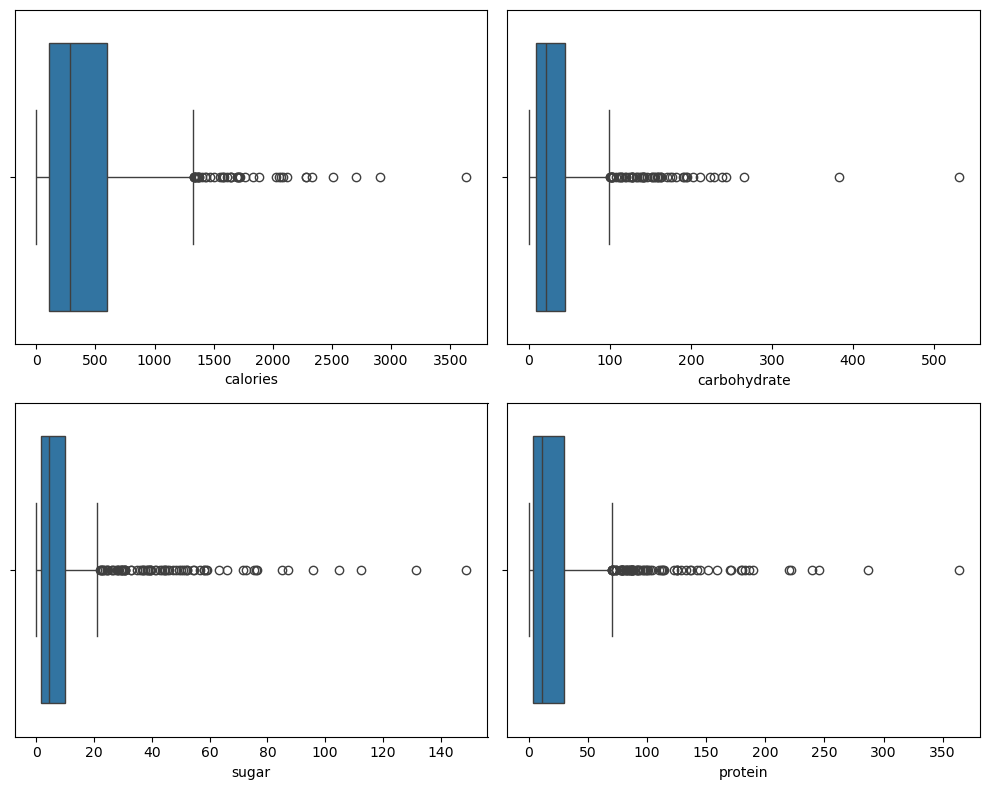

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for col, ax in zip(df.select_dtypes(include="float"), axes.flat):
    sns.boxplot(data=df, x=col, ax=ax)

plt.tight_layout()
plt.show()

Not much interesting to see here, just that there is a wide range of recipes when it comes to the calories and macros. Very reasonable since the recipe types span from beverages to 6 serving meals.

### Single variable graphic 2 and first multi variable graphic: category distribution, overall and by traffic

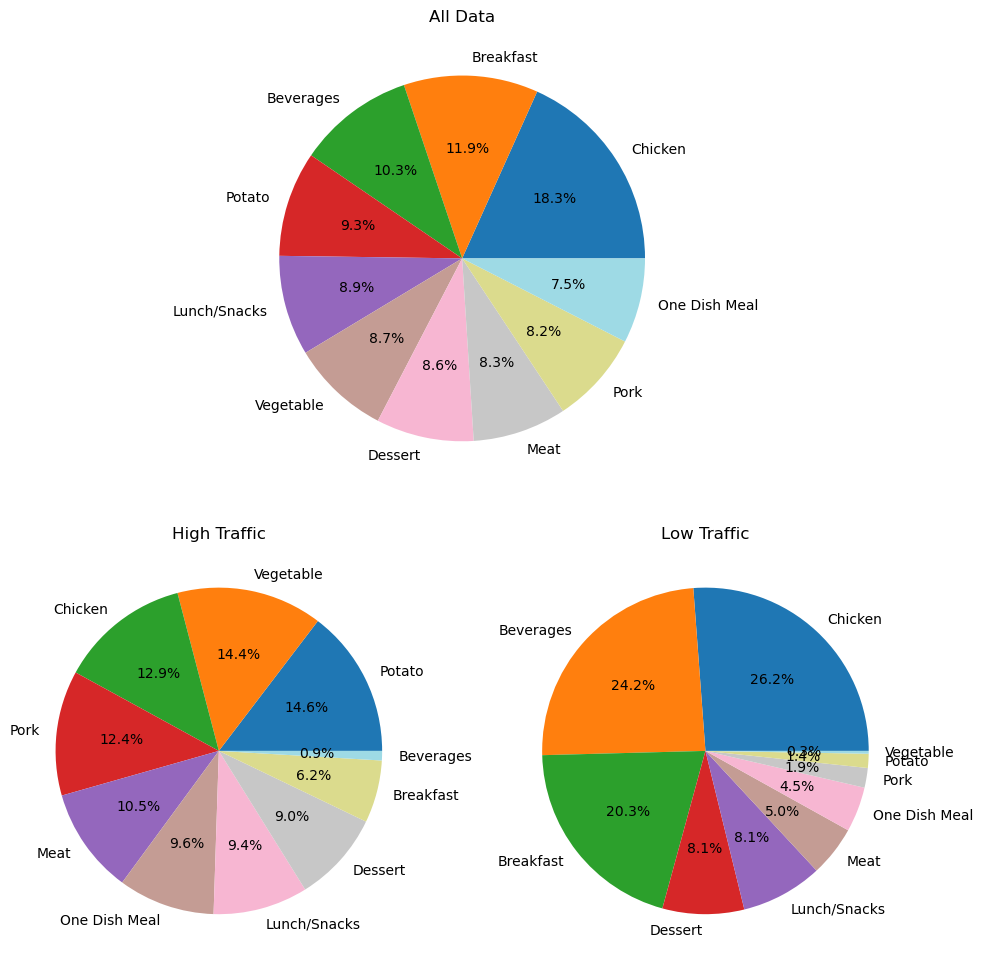

In [14]:
counts_all = df["category"].value_counts()
counts_high = df[df["high_traffic"] == True]["category"].value_counts()
counts_low = df[df["high_traffic"] == False]["category"].value_counts()

fig = plt.figure(figsize=(10, 10))
ax_top = plt.subplot2grid((2, 2), (0, 0), colspan=2)
ax_bottom_left = plt.subplot2grid((2, 2), (1, 0))
ax_bottom_right = plt.subplot2grid((2, 2), (1, 1))

counts_all.plot(
    kind="pie",
    ax=ax_top,
    autopct="%1.1f%%", # show % on 1 decimal
    title="All Data",
    ylabel="",
    cmap="tab20",
)
counts_high.plot(
    kind="pie",
    ax=ax_bottom_left,
    autopct="%1.1f%%",
    title="High Traffic",
    ylabel="",
    cmap="tab20",
)
counts_low.plot(
    kind="pie",
    ax=ax_bottom_right,
    autopct="%1.1f%%",
    title="Low Traffic",
    ylabel="",
    cmap="tab20",
)

plt.tight_layout()
plt.show()

Now here we see something interesting which eludes to a possible answer to the overall question. The overall recipe set has a very equal distribution over all categories, with only chicken being slightly more used, but a big difference emerges if we differ between high and low traffic. People seem to be interested in recipes like the vegetable and potato categories, while there also seems to be a big disinterest in beverages and breakfast, while chicken is also slightly unpopular. In this step we have made the natural transition from single variable characteristics to multivariable, let's see if we can find some more information between other variable combinations.

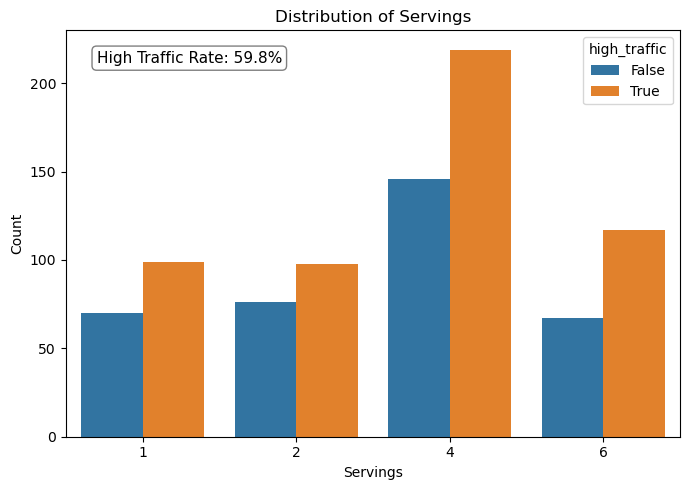

In [15]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="servings",
    hue="high_traffic",
    palette="tab10",
    legend=True,
)

high_traffic_rate = len(df[df["high_traffic"]==True])/len(df)*100
ax.text(
    0.05, 0.95,               
    f"High Traffic Rate: {high_traffic_rate:.1f}%", 
    transform=ax.transAxes,                       
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1)
)
plt.title("Distribution of Servings")
plt.xlabel("Servings")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

No huge differences here: 4 servings is in both high and low traffic cases the most occuring entry, 6 servings does better than 1 or 2. We can also see the high traffic numbers relative to low traffic, with the high traffic rate in the top left, it is around 60\% as it is, we want to upper that to 80\%.

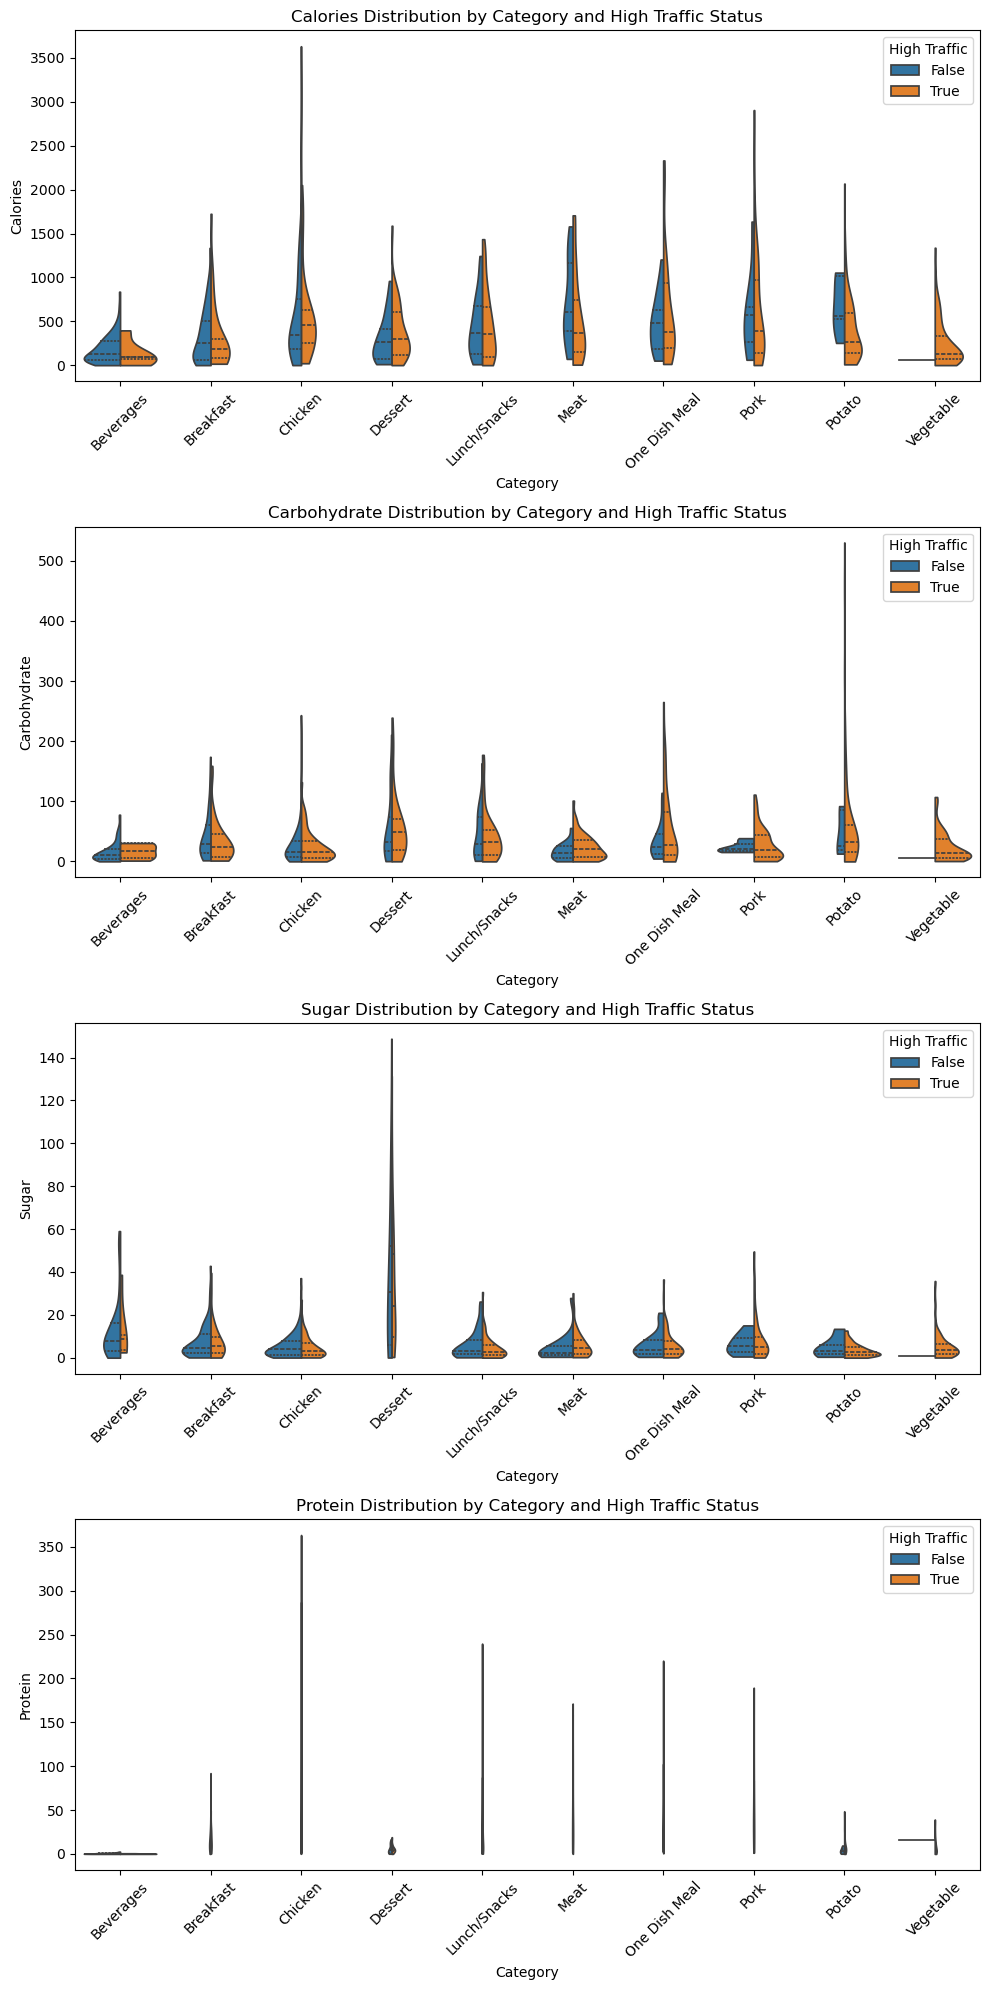

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

for i, col in enumerate(df.columns[:4]):
    sns.violinplot(
        data=df,
        x="category",
        y=col,
        hue="high_traffic",
        split=True,
        inner="quart",
        ax=axes[i],
        cut=0 # we obviously have no negative calories
    )
    axes[i].set_title(f"{col.capitalize()} Distribution by Category and High Traffic Status")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].set_ylabel(f"{col.capitalize()}")
    axes[i].set_xlabel("Category")
    axes[i].legend(title = "High Traffic")
plt.tight_layout()
plt.show()

In the violinplots we can retrieve the characteristics of the different foods, like deserts having a wide spread in sugar amount and meat types having a wide spread in protein. An interesting point to be made is that lower calorie meat, pork, vegetable, potato and one dish meal recipes do better if they contain less calories.

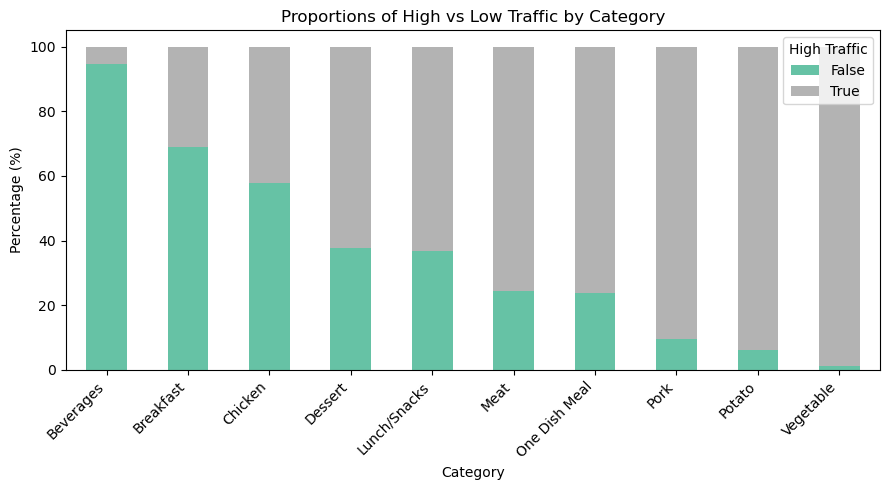

In [17]:
ct = pd.crosstab(df["category"], df["high_traffic"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="Set2")
plt.ylabel("Percentage (%)")
plt.xlabel("Category")
plt.title("Proportions of High vs Low Traffic by Category")
plt.xticks(rotation=45, ha="right")
plt.legend(title="High Traffic")
plt.tight_layout()
plt.show()

Here we have a better visualisation of what we've concluded before: vegetable recipes do extremely well, just as potato and pork recipes.

## 3. Model Development

To build on this, we set up a **binary classification** model to predict whether a recipe will be high traffic (1) or low traffic (0). Because our main business goal is to minimize the risk of displaying low traffic recipes, we prioritize average precision as our guiding metric to evaluate how reliably models rank popular recipes at the top. To ensure a complete evaluation, we also track precision (the percentage of selected recipes that are genuinely popular), recall (how many total popular recipes we caught), and ROC-AUC (the overall ability to separate high traffic from low traffic dishes) so we can fine tune our final recommendation cutoff with confidence.

I use **logistic regression as the baseline model** (simple, interpretable, a natural first choice for a binary target) and **random forest as the comparison model** (it can capture non linear effects and interactions between category and nutrition values). Ridge classifier and decision tree are also fitted as supporting results.

In [18]:
X = df.drop(columns="high_traffic")
X = pd.get_dummies(X)
y = df["high_traffic"].astype("int")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=20
)

# Let's try 4 different classifiers and gridsearch through some parameters settings to find the best possible model. Let's take logistic regression as the baseline model.
estimators = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Ridge Classifier": RidgeClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

param_grids = {
    "Logistic Regression": {
        "model__C": [0.0005, 0.001, 0.01, 0.1, 1.0, 10.0],
        "model__solver": ["liblinear", "lbfgs"],
    },
    "Ridge Classifier": {"model__alpha": [0.1, 1.0, 10.0, 100.0, 300.0, 500.0]},
    "Decision Tree": {
        "model__max_depth": [3, 5, 10, None],
        "model__min_samples_split": [2, 5, 10],
    },
    "Random Forest": {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [3, 5, 10],
    },
}

# Let's show 3 other metrics, but we gridsearch on average precision.
scoring_metrics = {
    "average_precision": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
}

# Use 5 split validation.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state= 20)
best_models = {}

for name, model in estimators.items():
    pipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", model),
        ]
    )

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=cv_strategy,
        scoring=scoring_metrics,
        refit="average_precision",
        n_jobs=-1,
    )

    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    best_idx = grid_search.best_index_

    cv_pr_auc = grid_search.cv_results_["mean_test_average_precision"][best_idx]
    cv_precision = grid_search.cv_results_["mean_test_precision"][best_idx]
    cv_recall = grid_search.cv_results_["mean_test_recall"][best_idx]
    cv_roc_auc = grid_search.cv_results_["mean_test_roc_auc"][best_idx]

    print(f"=== {name} ===")
    print(f"Best Params: {grid_search.best_params_}")
    print(f"PR-AUC:   {cv_pr_auc:.4f}")
    print(f"Precision: {cv_precision:.4f}")
    print(f"Recall:    {cv_recall:.4f}")
    print(f"ROC-AUC:   {cv_roc_auc:.4f}\n")


=== Logistic Regression ===
Best Params: {'model__C': 0.01, 'model__solver': 'lbfgs'}
PR-AUC:   0.8798
Precision: 0.7571
Recall:    0.8498
ROC-AUC:   0.8304

=== Ridge Classifier ===
Best Params: {'model__alpha': 300.0}
PR-AUC:   0.8810
Precision: 0.7855
Recall:    0.8216
ROC-AUC:   0.8321

=== Decision Tree ===
Best Params: {'model__max_depth': 5, 'model__min_samples_split': 10}
PR-AUC:   0.8041
Precision: 0.7682
Recall:    0.8333
ROC-AUC:   0.7839

=== Random Forest ===
Best Params: {'model__max_depth': 5, 'model__n_estimators': 200}
PR-AUC:   0.8754
Precision: 0.7150
Recall:    0.9062
ROC-AUC:   0.8249



After searching though the hyperparameter settings, linear models with strong regularization emerged as the clear winners for predicting high traffic recipes. Ridge classifier (alpha=300.0) and logistic regression (C=0.01) achieved the highest cross-validation pr_auc (average precision) scores, outperforming single decision trees. While random forest achieved the highest recall, it did so at the expense of precision, failing our core constraint of minimizing unpopular recipes. Now let's use the 4 hyperparameter optimized models on the test set.

## 4. Model Evaluation

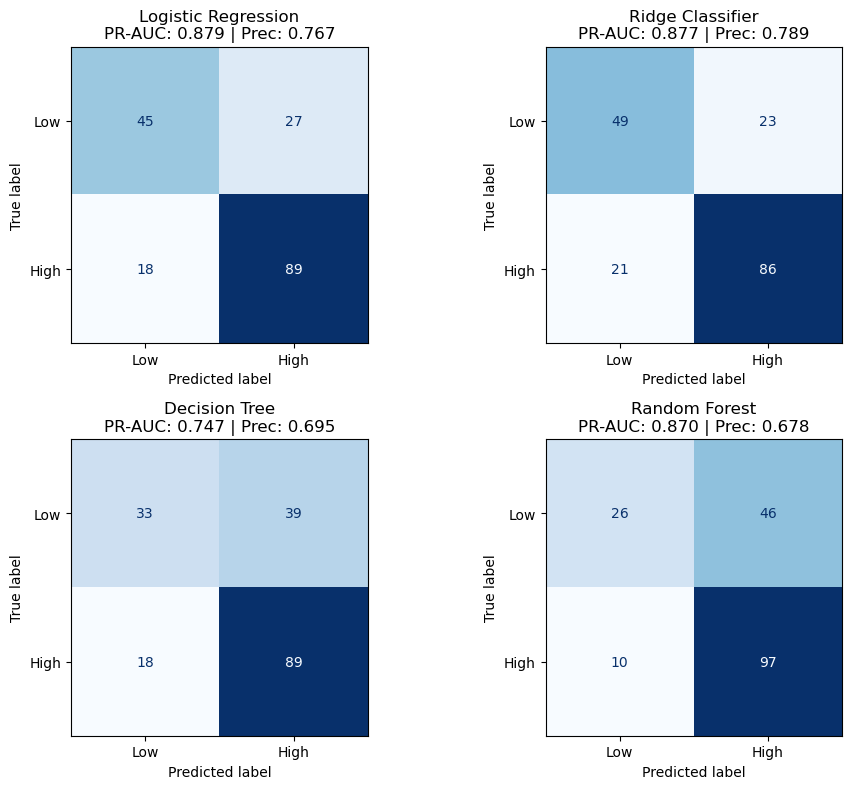

=== Test Set Evaluation Summary ===
              Model  Test PR-AUC  Test Precision  Test Recall  Test ROC-AUC
Logistic Regression     0.878627        0.767241     0.831776      0.822040
   Ridge Classifier     0.877285        0.788991     0.803738      0.820093
      Random Forest     0.870212        0.678322     0.906542      0.798546
      Decision Tree     0.746635        0.695312     0.831776      0.689187


In [19]:
test_results = []

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (name, model) in enumerate(best_models.items()):

    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"): # to account for ridge
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)

    test_pr_auc = average_precision_score(y_test, y_probs)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_probs)

    test_results.append(
        {
            "Model": name,
            "Test PR-AUC": test_pr_auc,
            "Test Precision": test_precision,
            "Test Recall": test_recall,
            "Test ROC-AUC": test_roc_auc,
        }
    )

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Low", "High"]
    )
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(
        f"{name}\nPR-AUC: {test_pr_auc:.3f} | Prec: {test_precision:.3f}"
    )

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(test_results).sort_values(
    by="Test PR-AUC", ascending=False
)
print("=== Test Set Evaluation Summary ===")
print(summary_df.to_string(index=False))

On the unseen test set, logistic regression and ridge classifier performed almost identically. Both reached a precision of just under 80\% and a recall of just above 80\%, they also score close together for both PR AUC and ROC AUC. Random forest beat their recall but had lower precision, and the decision tree was clearly the weakest model. Because the two linear models are so close, I choose logistic regression as the final model since it is simple, and its coefficients are easy to interpret. At the default 0.5 cutoff its precision of 77\% is below the business target of 80%. Precision can be raised by increasing the classification threshold, at the cost of recall, so I examine that tradeoff next.

## 5. Business Metric

The business metric to monitor is the **precision of featured recipes**, meaning the share of recipes shown on the homepage that actually lead to high traffic. It should be tracked weekly or monthly against the 80% target.

Standard logistic regression uses a probability cutoff of 0.5, above which a recipe is predicted as high traffic. We move this threshold around to see at what level we reach the requested precision of 80%.

In [20]:
y_probs = best_models["Logistic Regression"].predict_proba(X_test)[:, 1]

thresholds = np.arange(0.3, 0.9, 0.02)
threshold_results = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    count_selected = y_pred.sum()

    threshold_results.append(
        {
            "Threshold": round(t, 2),
            "Precision": round(p, 4),
            "Recall": round(r, 4),
            "Recipes Featured": count_selected,
        }
    )

results_df = pd.DataFrame(threshold_results)
print(results_df)

    Threshold  Precision  Recall  Recipes Featured
0        0.30     0.6485  1.0000               165
1        0.32     0.6485  1.0000               165
2        0.34     0.6485  1.0000               165
3        0.36     0.6485  1.0000               165
4        0.38     0.6485  1.0000               165
5        0.40     0.6564  1.0000               163
6        0.42     0.6842  0.9720               152
7        0.44     0.7063  0.9439               143
8        0.46     0.7021  0.9252               141
9        0.48     0.7176  0.8785               131
10       0.50     0.7672  0.8318               116
11       0.52     0.7870  0.7944               108
12       0.54     0.7944  0.7944               107
13       0.56     0.8077  0.7850               104
14       0.58     0.8039  0.7664               102
15       0.60     0.8000  0.7477               100
16       0.62     0.8022  0.6822                91
17       0.64     0.8571  0.6168                77
18       0.66     0.8514  0.588

To meet the business requirement that at least 80% of featured recipes are high traffic, I raised the classification threshold of the tuned logistic regression model. Moving from the default 0.50 cutoff to 0.56 increases precision from 77% to 80%, so roughly 8 out of 10 featured recipes are genuinely high traffic. The cost is recall, which falls from 83% to 79%. However, 0.56 only just clears the target, and because it was chosen by looking at test set results, the margin is not reliable. The neighbouring thresholds of 0.54 and 0.58 give 79% and 80%, so the result sits right on the line. To be more certain of meeting the target, I therefore select a stricter threshold of 0.65. Around this value precision rises to roughly 85%, which gives a comfortable buffer above 80%. The tradeoff is that recall falls to roughly 59% to 62%, and only about 77 to 91 of the 165 test recipes are featured, compared with 104 at 0.56. This is acceptable for the business case, because the homepage shows a single recipe per day, so a smaller pool of high confidence recipes is enough, and showing an unpopular recipe is the costlier mistake.

The grid above steps in 0.02, so 0.65 was not evaluated directly. The cell below prints the exact values at the chosen threshold, together with the starting value of the metric (the overall share of high traffic recipes, which is what picking a recipe without a model would give on average).

In [21]:
threshold = 0.65

y_pred_final = (y_probs >= threshold).astype(int)
final_precision = precision_score(y_test, y_pred_final, zero_division=0)
final_recall = recall_score(y_test, y_pred_final, zero_division=0)

print(f"Threshold: {threshold}")
print(f"Precision of featured recipes: {final_precision:.3f}")
print(f"Recall: {final_recall:.3f}")
print(f"Recipes featured: {y_pred_final.sum()} of {len(y_test)}")
print("Confusion matrix (rows = actual Low/High, columns = predicted Low/High):")
print(confusion_matrix(y_test, y_pred_final))

print(f"\nStarting value of the metric (overall share of high traffic recipes): {y.mean():.3f}")

Threshold: 0.65
Precision of featured recipes: 0.853
Recall: 0.598
Recipes featured: 75 of 179
Confusion matrix (rows = actual Low/High, columns = predicted Low/High):
[[61 11]
 [43 64]]

Starting value of the metric (overall share of high traffic recipes): 0.598


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_13460\3477884808.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_test_recipes.groupby("category")["high_traffic_probability"]
C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_13460\3477884808.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


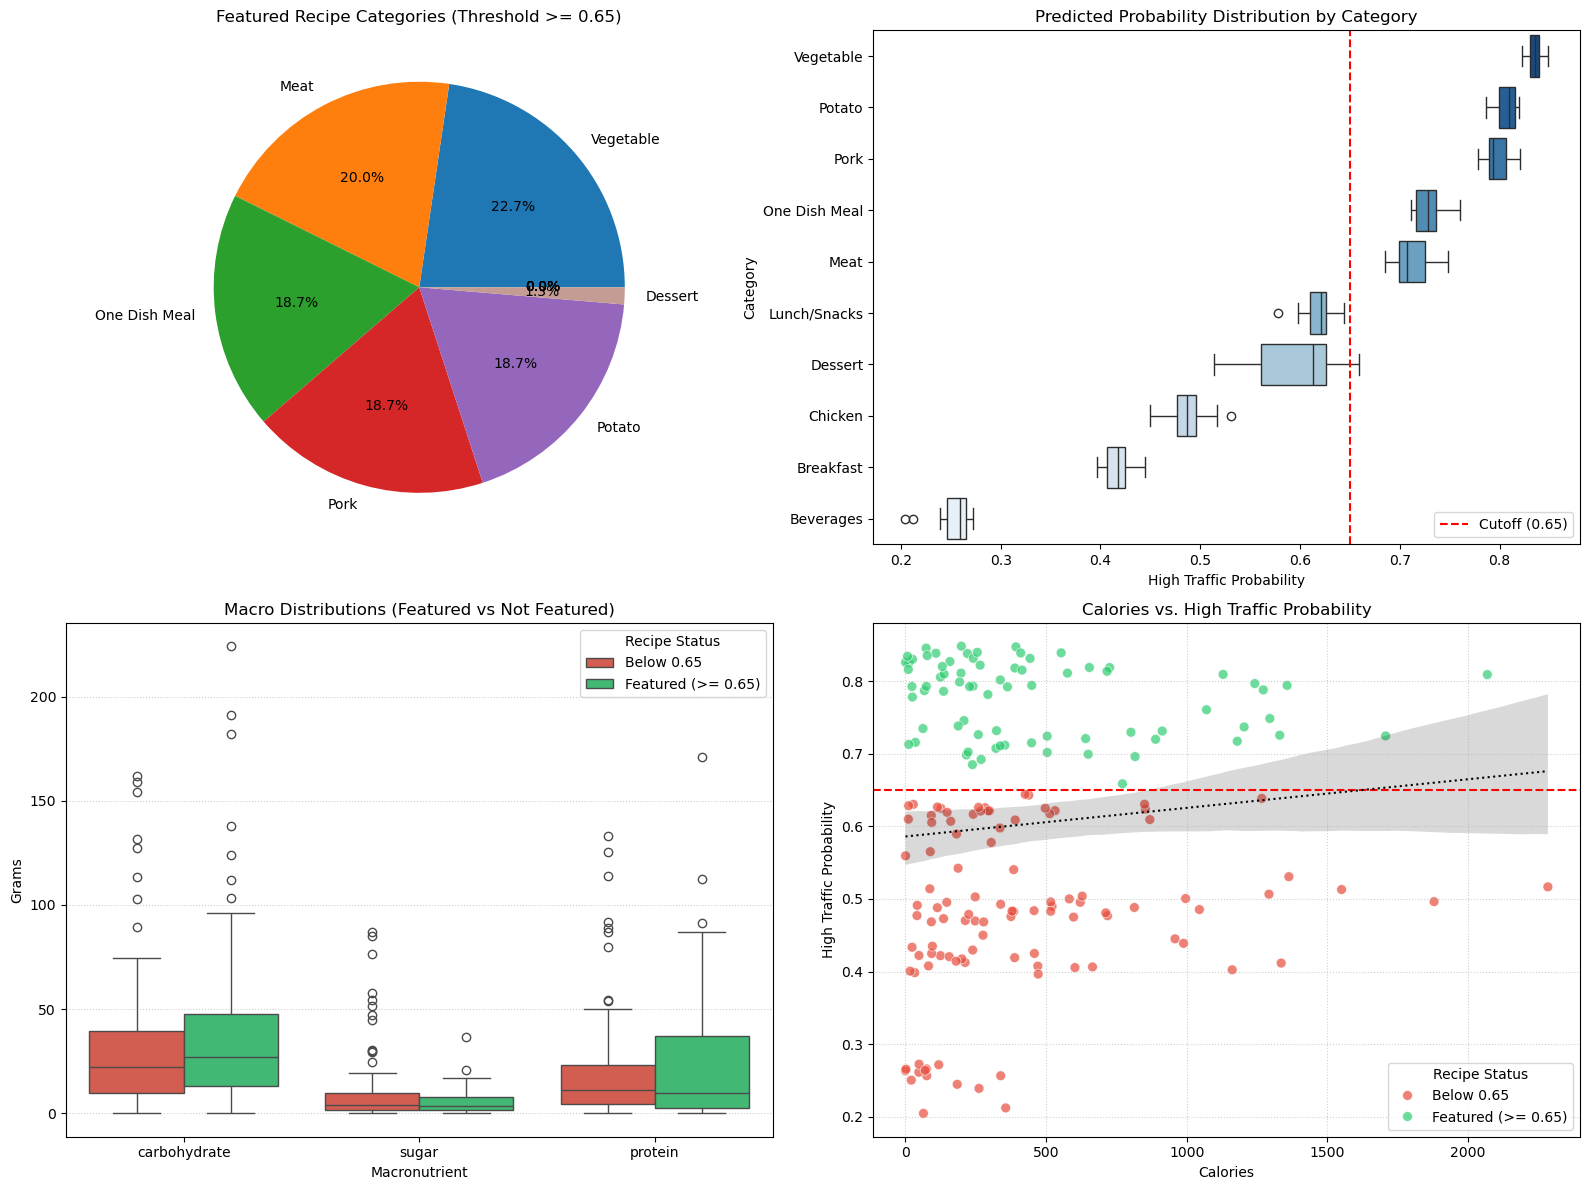

In [22]:
is_featured = y_probs >= threshold

featured_test_recipes = df.loc[X_test.index[is_featured]].copy()
featured_test_recipes["high_traffic_probability"] = y_probs[is_featured]

all_test_recipes = df.loc[X_test.index].copy()
all_test_recipes["high_traffic_probability"] = y_probs
all_test_recipes["Featured"] = all_test_recipes["high_traffic_probability"] >= threshold

# Order categories by median predicted probability
category_order = (
    all_test_recipes.groupby("category")["high_traffic_probability"]
    .median()
    .sort_values(ascending=False)
    .index
)

macro_cols = ["carbohydrate", "sugar", "protein"]
melted_macros = all_test_recipes.melt(
    id_vars=["Featured"],
    value_vars=macro_cols,
    var_name="Macro",
    value_name="Grams",
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

category_counts = featured_test_recipes["category"].value_counts()
category_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    title=f"Featured Recipe Categories (Threshold >= {threshold})",
    ylabel="",
    cmap="tab20",
    ax=axes[0, 0],
)

sns.boxplot(
    data=all_test_recipes,
    y="category",
    x="high_traffic_probability",
    order=category_order,
    palette="Blues_r",
    ax=axes[0, 1],
)

axes[0, 1].axvline(
    x=threshold,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Cutoff ({threshold})",
)
axes[0, 1].set_title("Predicted Probability Distribution by Category")
axes[0, 1].set_xlabel("High Traffic Probability")
axes[0, 1].set_ylabel("Category")
axes[0, 1].legend(loc="lower right")

sns.boxplot(
    data=melted_macros,
    x="Macro",
    y="Grams",
    hue="Featured",
    palette={True: "#2ecc71", False: "#e74c3c"},
    ax=axes[1, 0],
)

axes[1, 0].set_title("Macro Distributions (Featured vs Not Featured)")
axes[1, 0].set_xlabel("Macronutrient")
axes[1, 0].set_ylabel("Grams")
axes[1, 0].grid(axis="y", linestyle=":", alpha=0.6)

handles, labels = axes[1, 0].get_legend_handles_labels()
axes[1, 0].legend(handles=handles, labels=[f"Below {threshold}", f"Featured (>= {threshold})"], title="Recipe Status")

sns.scatterplot(
    data=all_test_recipes,
    x="calories",
    y="high_traffic_probability",
    hue="Featured",
    palette={True: "#2ecc71", False: "#e74c3c"},
    alpha=0.7,
    s=50,
    ax=axes[1, 1],
)

axes[1, 1].axhline(
    y=threshold,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Cutoff ({threshold})",
)

sns.regplot(
    data=all_test_recipes,
    x="calories",
    y="high_traffic_probability",
    scatter=False,
    color="black",
    line_kws={"linestyle": ":", "linewidth": 1.5},
    ax=axes[1, 1],
)

axes[1, 1].set_title("Calories vs. High Traffic Probability")
axes[1, 1].set_xlabel("Calories")
axes[1, 1].set_ylabel("High Traffic Probability")
axes[1, 1].grid(linestyle=":", alpha=0.6)

handles_sc, labels_sc = axes[1, 1].get_legend_handles_labels()
axes[1, 1].legend(handles=handles_sc[:2], labels=[f"Below {threshold}", f"Featured (>= {threshold})"], title="Recipe Status")

plt.tight_layout()
plt.show()

To summarize, we built multiple models and chose the logistic regression model with tuned hyperparameters to predict high traffic versus low traffic recipes. To avoid showing unpopular recipes, we raised the probability threshold to 0.65, which lifts precision above the 80% target on the test set. The business metric to monitor is the precision of featured recipes, meaning the share of recipes shown on the homepage that actually lead to high traffic. It should be tracked weekly or monthly against the 80% target. Based on current data, the manager’s present approach of picking a favourite is comparable to picking at random, which gives a starting value of about 60% (the overall share of high traffic recipes). The model at a 0.65 threshold reaches roughly 85% on the test set, so the expected improvement is about 25 percentage points. This is likely a slightly optimistic estimate, since the threshold was chosen on the test set. In conclusion, category is what really drives traffic, while calories, carbs, and protein do not seem to make a difference. We should focus on top performers like vegetables, potatoes, pork, meat, and one dish meals. Low performers like beverages, breakfast, and chicken should be dialed back. If we still want drinks on the homepage, we will need a category specific rule, since almost none pass the 0.65 cutoff naturally. Lastly, there is no need to filter by macros, since lower sugar in featured recipes is a side effect of cutting out desserts and drinks, not a driver on its own.